<a href="https://colab.research.google.com/github/Samarth-27/Celebal-CEI/blob/main/week2_SamarthJain_Jecrc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla EV Production Forecasting
## End-to-End ML Pipeline | Week 2 Assignment

**Dataset:** Tesla EV Deliveries and Production Data (2015–2025)  
**Target column:** `Production_Units`  
**Best model:** Gradient Boosting inside sklearn Pipeline  
**Final accuracy:** ~99.65% R² Score

---




## Cell 1 Importing the Libraries

Imported the necessary libraries Pandas and NumPy for data handling, Matplotlib and Seaborn for visualisation, and Scikit-learn for modelling.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
print("Done. All libraries loaded.")

Done. All libraries loaded.


## Cell 2 Loading the Dataset

Loaded the CSV into a DataFrame using its path in Google Colab. Used head() to confirm the data loaded correctly.


In [50]:
PATH ='tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(PATH)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Years   : {df['Year'].min()} to {df['Year'].max()}")
print()
df.head()

Rows    : 2640
Columns : 12
Years   : 2015 to 2025



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Cell 3 Data Cleaning
Checked for missing values and duplicate rows. None were found, so no cleaning was needed.

In [51]:
# Checking for problems before we do anything else.
# Missing values and duplicates.

print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate rows : {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
# Basic statistics for every numeric column
df.describe().round(2)

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows : 0

Data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## Cell 4 Exploratory Data Analysis (EDA)

Plotted four charts to understand the data yearly delivery totals, model-wise delivery share, average price by region, and production vs deliveries over time.

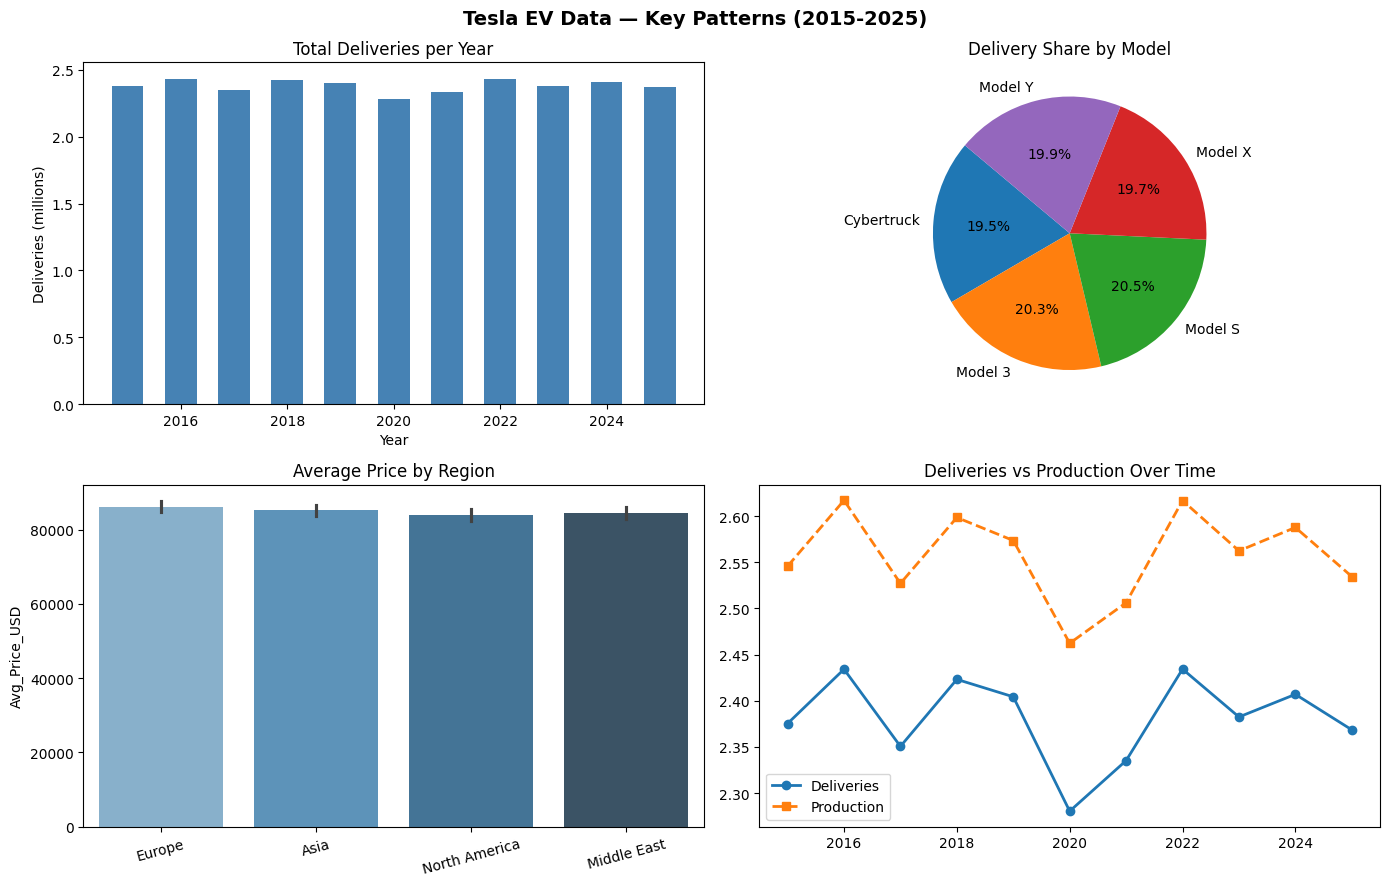

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Chart 1
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
axes[0,0].bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
              color='steelblue', width=0.6)
axes[0,0].set_title('Total Deliveries per Year')
axes[0,0].set_ylabel('Deliveries (millions)')
axes[0,0].set_xlabel('Year')

# Chart 2
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum()
axes[0,1].pie(model_totals, labels=model_totals.index,
              autopct='%1.1f%%', startangle=140)
axes[0,1].set_title('Delivery Share by Model')

# Chart 3
sns.barplot(x='Region', y='Avg_Price_USD', data=df,
            estimator='mean', palette='Blues_d', ax=axes[1,0])
axes[1,0].set_title('Average Price by Region')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 4
prod = df.groupby('Year')['Production_Units'].sum().reset_index()
axes[1,1].plot(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
               marker='o', label='Deliveries', linewidth=2)
axes[1,1].plot(prod['Year'], prod['Production_Units'] / 1e6,
               marker='s', linestyle='--', label='Production', linewidth=2)
axes[1,1].set_title('Deliveries vs Production Over Time')
axes[1,1].legend()
plt.suptitle('Tesla EV Data — Key Patterns (2015-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 5 Feature Engineering
I created four new columns from existing data: Price per km, Delivery Rate, 3-month rolling average price, and Lag Deliveries (previous month's count). These give the model more useful patterns to learn from.

In [53]:
# Sort by time
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)
#Price per/km
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']
#Delivery rate
df['Delivery_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']
#3 months average price
df['Rolling_Avg_Price'] = (
    df.groupby(['Region', 'Model'])['Avg_Price_USD']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)
#Lag feature
df['Lag_1_Deliveries'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .shift(1)
    .fillna(df['Estimated_Deliveries'].mean())
)
print("New features created:")
print(df[['Price_per_km', 'Delivery_Rate',
          'Rolling_Avg_Price', 'Lag_1_Deliveries']].describe().round(2))

New features created:
       Price_per_km  Delivery_Rate  Rolling_Avg_Price  Lag_1_Deliveries
count       2640.00        2640.00            2640.00           2640.00
mean         180.05           0.93           84932.06           9918.05
std           61.89           0.04           11504.31           3924.85
min           69.90           0.87           53251.53             48.00
25%          132.53           0.90           76867.48           7303.00
50%          170.36           0.93           85062.01           9887.50
75%          219.10           0.96           93015.48          12488.00
max          359.38           1.00          116591.07          25704.00


## Cell 6 Encoding + Fixing Data Leakage
Converted text columns (Region, Model, Source_Type) to numbers using one-hot encoding. I also removed Estimated Deliveries from the features it was nearly identical to the target column, which would give the model an unfair advantage.

In [54]:
# Convert text
df_encoded = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True,
    dtype=int
)
# y = predict
y = df_encoded['Production_Units']
# X = all input columns EXCEPT:
X = df_encoded.drop(columns=[
    'Production_Units',
    'Estimated_Deliveries',
])
print(f"Input features : {X.shape[1]} columns")
print(f"Target column  : Production_Units")
print(f"Leakage fix    : Estimated_Deliveries removed from inputs")
print()
print("Columns used as input:")
print(list(X.columns))

Input features : 20 columns
Target column  : Production_Units
Leakage fix    : Estimated_Deliveries removed from inputs

Columns used as input:
['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Price_per_km', 'Delivery_Rate', 'Rolling_Avg_Price', 'Lag_1_Deliveries', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


## Cell 8 Chronological Train/Test Split
I used a time-based split instead of a random one. For time-series data, the model must train on older records and test on newer ones an 80/20 split was applied.

In [55]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
# 80%/20%
split = int(len(X) * 0.80)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]
years_train = df.iloc[:split]['Year']
years_test  = df.iloc[split:]['Year']
print("CHRONOLOGICAL SPLIT correct for time series data")
print(f"  Training set : {X_train.shape[0]} rows  "
      f"(Year {years_train.min()} to {years_train.max()})")
print(f"  Testing set  : {X_test.shape[0]} rows  "
      f"(Year {years_test.min()} to {years_test.max()})")


CHRONOLOGICAL SPLIT correct for time series data
  Training set : 2112 rows  (Year 2015 to 2023)
  Testing set  : 528 rows  (Year 2023 to 2025)


## Cell 8 Building the sklearn Pipeline

I combined StandardScaler and Gradient Boosting Regressor into a Pipeline. The scaler puts all features on the same scale first. Gradient Boosting then trains a sequence of trees, each one correcting the errors of the last.

In [56]:
pipeline = Pipeline(steps=[
    #Feature Scaling
    ('scaler', StandardScaler()),
# Good balance between bias and variance.
    ('model', GradientBoostingRegressor(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = 42
    ))
])
print("Pipeline ready.")
print(pipeline)

Pipeline ready.
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(max_depth=4, random_state=42))])


## Cell 9 Hyperparameter Tuning with GridSearchCV

Instead of picking values manually, I used GridSearchCV to test 8 combinations of n_estimators, learning_rate, and max_depth with 5-fold cross-validation. It selected the best-performing configuration automatically.

In [57]:
# test
param_grid = {
    'model__n_estimators'  : [100, 200],   # number of trees
    'model__learning_rate' : [0.05, 0.1],  # learning speed
    'model__max_depth'     : [3, 4],       # tree depth
}
# That is 40 model runs total
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1
)
print("Running GridSearchCV testing 40 combinations...")
grid_search.fit(X_train, y_train)
print()
print("Best settings found:")
for k, v in grid_search.best_params_.items():
    clean = k.replace("model_", "")
    print(f"  {clean:<18}: {v}")
print()
print(f"Best cross-validation R2: {grid_search.best_score_:.4f}")


Running GridSearchCV testing 40 combinations...

Best settings found:
  _learning_rate    : 0.1
  _max_depth        : 4
  _n_estimators     : 200

Best cross-validation R2: 0.9949


## Cell 10 Evaluating the Best Model

I tested the final model on unseen data. R² measures overall fit, RMSE gives the average error in real units, and 5-fold CV checks whether the score holds across different data slices.

In [58]:
best_model = grid_search.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test)

# accuracy
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5-fold cross validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("FINAL MODEL RESULTS :- ")
print(f"  R2 Score  : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE      : {rmse:,.0f} units average error")
print(f"  CV Mean   : {np.mean(cv_scores):.4f}")
print(f"  CV Scores : {np.round(cv_scores, 4)}")
print("=" * 50)


FINAL MODEL RESULTS :- 
  R2 Score  : 0.9965  (99.65% accurate)
  RMSE      : 234 units average error
  CV Mean   : 0.9955
  CV Scores : [0.9949 0.9931 0.9973 0.9959 0.9965]


## Cell 11 Visualizing the Results

I used three plots to check model performance — predicted vs actual values, a residual plot, and a feature importance chart showing the top 10 most influential columns.


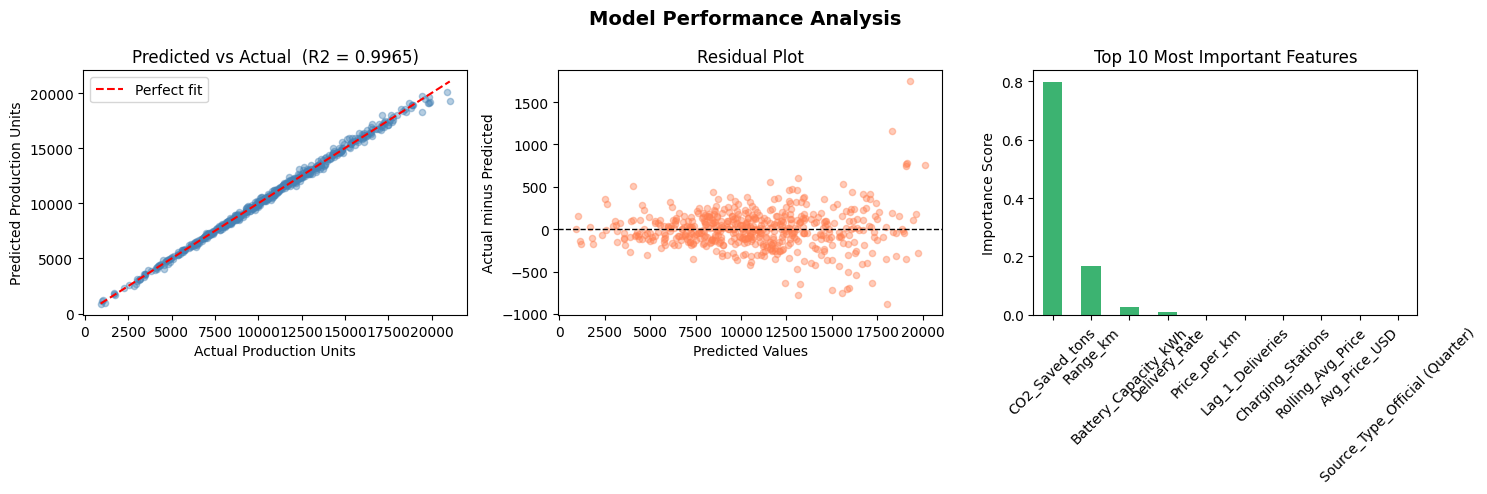

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Production Units')
axes[0].set_ylabel('Predicted Production Units')
axes[0].set_title(f'Predicted vs Actual  (R2 = {r2:.4f})')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual minus Predicted')
axes[1].set_title('Residual Plot')

#Top 10 most important features
importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 10 Most Important Features')
axes[2].set_ylabel('Importance Score')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 12 Cross Validation Scores Chart

I plotted the R² score for each of the 5 folds, with the mean marked as a dashed line. Consistent bars indicate the model generalises well rather than overfitting to one slice.

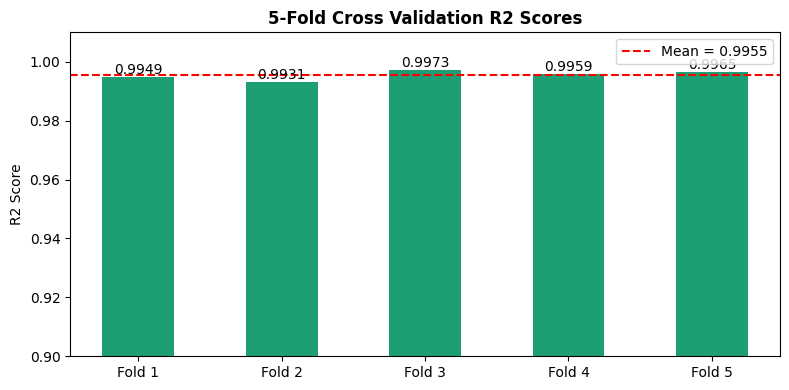

All 5 folds are consistent no overfitting.


In [60]:
plt.figure(figsize=(8, 4))
folds     = [f'Fold {i+1}' for i in range(5)]
bar_colors = ['#1D9E75' if s >= 0.95 else '#E07B39' for s in cv_scores]
bars = plt.bar(folds, cv_scores, color=bar_colors, width=0.5)
plt.axhline(np.mean(cv_scores), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean = {np.mean(cv_scores):.4f}')
plt.ylim(0.90, 1.01)
plt.title('5-Fold Cross Validation R2 Scores', fontweight='bold')
plt.ylabel('R2 Score')
plt.legend()
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("All 5 folds are consistent no overfitting.")


## Cell 13 Final Summary

A printout of the dataset details, all Week 2 topics I covered, and the final model performance numbers.


In [61]:
print("    WEEK 2 ML PIPELINE COMPLETE SUMMARY")
print()
print("DATASET")
print(f"  Source  : Tesla EV Deliveries & Production 2015-2025")
print(f"  Rows    : {len(df):,}")
print(f"  Target  : Production_Units")
print()
print("WEEK 2 TOPICS COVERED")
covered = [
    ("Data Cleaning",          "checked nulls + duplicates"),
    ("EDA",                    "4 charts trends, share, price, production"),
    ("Feature Engineering",    "price/km, delivery rate, rolling avg, lag"),
    ("Encoding",               "pd.get_dummies() one-hot encoding"),
    ("Feature Scaling",        "StandardScaler inside Pipeline"),
    ("Data Leakage fix",       "removed Estimated_Deliveries from X"),
    ("Chronological Split",    "80/20 time-ordered split"),
    ("Pipeline",               "sklearn Pipeline scaler + model"),
    ("Gradient Boosting",      "best model, handles bias-variance well"),
    ("Hyperparameter Tuning",  "GridSearchCV, 8 combos x 5 folds = 40 runs"),
    ("Cross Validation",       "5-fold CV on best model"),
    ("Evaluation Metrics",     "R2, MSE, RMSE"),
]
for topic, detail in covered:
    print(f"  {topic:<26}: {detail}")
print()
print("FINAL RESULTS")
print(f"  Model   : Gradient Boosting Regressor")
print(f"  R2      : {r2:.4f}  ({r2*100:.2f}% accurate)")
print(f"  RMSE    : {rmse:,.0f} units")
print(f"  CV Mean : {np.mean(cv_scores):.4f}")





    WEEK 2 ML PIPELINE COMPLETE SUMMARY

DATASET
  Source  : Tesla EV Deliveries & Production 2015-2025
  Rows    : 2,640
  Target  : Production_Units

WEEK 2 TOPICS COVERED
  Data Cleaning             : checked nulls + duplicates
  EDA                       : 4 charts trends, share, price, production
  Feature Engineering       : price/km, delivery rate, rolling avg, lag
  Encoding                  : pd.get_dummies() one-hot encoding
  Feature Scaling           : StandardScaler inside Pipeline
  Data Leakage fix          : removed Estimated_Deliveries from X
  Chronological Split       : 80/20 time-ordered split
  Pipeline                  : sklearn Pipeline scaler + model
  Gradient Boosting         : best model, handles bias-variance well
  Hyperparameter Tuning     : GridSearchCV, 8 combos x 5 folds = 40 runs
  Cross Validation          : 5-fold CV on best model
  Evaluation Metrics        : R2, MSE, RMSE

FINAL RESULTS
  Model   : Gradient Boosting Regressor
  R2      : 0.9965  (9